In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import torch 
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn
import json
from PIL import Image
import torch.optim as optim
from torchvision.transforms import transforms
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torchvision.models as models

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data_dir="/kaggle/input/datasets/yocoder5768/solarimages/InfraredSolarModules"
json_dir="/kaggle/input/datasets/yocoder5768/solarimages/InfraredSolarModules/module_metadata.json"
img_path=[]
cls_path=[]
labels={
    "Cell":0,
    "Cracking":1,
    "Hot-Spot":2,
    "Hot-Spot-Multi":3,
    "Shadowing":4,
    "Diode":5,
     "Cell-Multi":6,
    "Diode-Multi":7,
    "Vegetation":8,
    "Soiling":9,
    "Offline-Module":10,
    "No-Anomaly":11
}
with open(json_dir,"r") as path:
    dictionary=json.load(path)
    for key,values in dictionary.items():
        for key,new_values in values.items():
            if (key=="image_filepath"):
                img_path.append(os.path.join(data_dir,new_values))
            elif(key=="anomaly_class"):
                mapped_labels = labels[new_values]
                cls_path.append(mapped_labels)
            
                    

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
class CustomDataset(Dataset):
    def __init__(self,features,labels,transforms):
        self.features=features
        self.labels=labels
        self.transforms=transforms
    def __len__(self):
        return len(self.features)
    def __getitem__(self,index):
        img_path = self.features[index]
        label = self.labels[index]
        image = Image.open(img_path).convert('RGB')
        if self.transforms:
            image = self.transforms(image)

        return image, torch.tensor(label, dtype=torch.long)


In [8]:
X_train,X_test,Y_train,Y_test=train_test_split(
    img_path,
    cls_path,
    test_size=0.2,
    stratify=cls_path,
    random_state=42
)
train_data=CustomDataset(X_train,Y_train,transforms=train_transforms)
test_data=CustomDataset(X_test,Y_test,transforms=test_transforms)
train_loaded=DataLoader(train_data,batch_size=32,shuffle=True)
test_loaded=DataLoader(test_data,batch_size=32,shuffle=False)
print(f"train data batches: {len(train_loaded)}, test data batches: {len(test_loaded)}")

train data batches: 500, test data batches: 125


In [9]:

class Neural(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()
        
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        base_model = models.convnext_tiny(weights=weights)
        
        self.encoder = base_model.features 
        self.avgpool = base_model.avgpool
    
        self.classifier = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=768, out_features=num_classes)
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(768, 384, 2, 2), nn.GELU(),
            nn.ConvTranspose2d(384, 192, 2, 2), nn.GELU(),
            nn.ConvTranspose2d(192, 96, 2, 2),  nn.GELU(),
            nn.ConvTranspose2d(96, 48, 2, 2),   nn.GELU(),
            nn.ConvTranspose2d(48, 3, 2, 2),    nn.Sigmoid() 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        class_preds = self.classifier(self.avgpool(encoded))
        reconstructed_img = self.decoder(encoded)
        return class_preds, reconstructed_img

model = Neural(num_classes=12)
model=model.to(device)

for param in model.parameters():
    param.requires_grad = False


for i in range(5, 8):
    for param in model.encoder[i].parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True
for param in model.decoder.parameters():
    param.requires_grad = True


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 197MB/s] 


In [10]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
    
        self.alpha = alpha 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
       
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
            
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [11]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight='balanced', classes=np.unique(Y_train), y=Y_train)

class_weights = torch.tensor(weights, dtype=torch.float)
criterion_class = FocalLoss(alpha=class_weights.to(device), gamma=2.0)
alpha_recon = 0.5

In [12]:


epochs = 50 
patience = 7  
trigger_times = 0
best_test_acc = 0.0
criterion_decoder = nn.MSELoss() 
alpha = 0.5 
optimizer = optim.AdamW([
    {'params': model.encoder[5].parameters(), 'lr': 1e-5},
    {'params': model.encoder[6].parameters(), 'lr': 1e-5},
    {'params': model.encoder[7].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
    {'params': model.decoder.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
print(f"Started training on {device}...\n")

for epoch in range(epochs):
    model.train() 
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loaded:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        class_preds, recon_imgs = model(images) 
        loss_class = criterion_class(class_preds, labels)
        loss_recon = criterion_decoder(decoder_imgs, images)
        loss = loss_class + (alpha * loss_recon)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        _, predicted = torch.max(class_preds.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_accuracy = 100 * correct_train / total_train

    model.eval() 
    running_test_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loaded:
            images, labels = images.to(device), labels.to(device)
        
            class_preds, decoder_imgs = model(images) 
        
            loss_class = criterion(class_preds, labels)
            loss_recon = criterion(decoder_imgs, images)
            loss = loss_class + (alpha * loss_recon)
            
            running_test_loss += loss.item()
            
            _, predicted = torch.max(class_preds.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    test_accuracy = 100 * correct_test / total_test
    scheduler.step(test_accuracy)
    current_lr = optimizer.param_groups[-2]['lr'] 
    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Train Acc: {train_accuracy:.2f}% | Test Acc: {test_accuracy:.2f}%")

    if test_accuracy > best_test_acc:
        print(f"Saving the best model")
        best_test_acc = test_accuracy
        torch.save(model.state_dict(), 'solar.pth') 
        trigger_times = 0 
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping in {epoch+1} ")
            break

print(f"Training completed with Best Accuracy: {best_test_acc:.2f}%")

Starting Two-Headed ConvNeXt Advanced training on cuda...

Epoch [1/50] | LR: 0.001000 | Train Acc: 39.23% | Test Acc: 44.55%
--> 🔥 Improvement! Saving model...
------------------------------
Epoch [2/50] | LR: 0.001000 | Train Acc: 51.84% | Test Acc: 42.25%
------------------------------
Epoch [3/50] | LR: 0.001000 | Train Acc: 56.12% | Test Acc: 59.15%
--> 🔥 Improvement! Saving model...
------------------------------
Epoch [4/50] | LR: 0.001000 | Train Acc: 58.19% | Test Acc: 62.73%
--> 🔥 Improvement! Saving model...
------------------------------
Epoch [5/50] | LR: 0.001000 | Train Acc: 59.75% | Test Acc: 59.95%
------------------------------
Epoch [6/50] | LR: 0.001000 | Train Acc: 61.10% | Test Acc: 59.67%
------------------------------
Epoch [7/50] | LR: 0.001000 | Train Acc: 63.29% | Test Acc: 67.95%
--> 🔥 Improvement! Saving model...
------------------------------
Epoch [8/50] | LR: 0.001000 | Train Acc: 64.34% | Test Acc: 64.78%
------------------------------
Epoch [9/50] | LR

Running final evaluation on the Test Set...

🎯 CLASSIFICATION REPORT (Precision & Recall)
                precision    recall  f1-score   support

          Cell       0.70      0.63      0.66       375
      Cracking       0.70      0.72      0.71       188
      Hot-Spot       0.45      0.68      0.54        50
Hot-Spot-Multi       0.37      0.63      0.47        49
     Shadowing       0.51      0.76      0.61       211
         Diode       0.89      0.95      0.92       300
    Cell-Multi       0.49      0.57      0.53       258
   Diode-Multi       0.84      0.91      0.88        35
    Vegetation       0.70      0.69      0.70       328
       Soiling       0.33      0.37      0.35        41
Offline-Module       0.40      0.72      0.51       165
    No-Anomaly       0.95      0.79      0.86      2000

      accuracy                           0.75      4000
     macro avg       0.61      0.70      0.65      4000
  weighted avg       0.79      0.75      0.77      4000


🎨 Generati

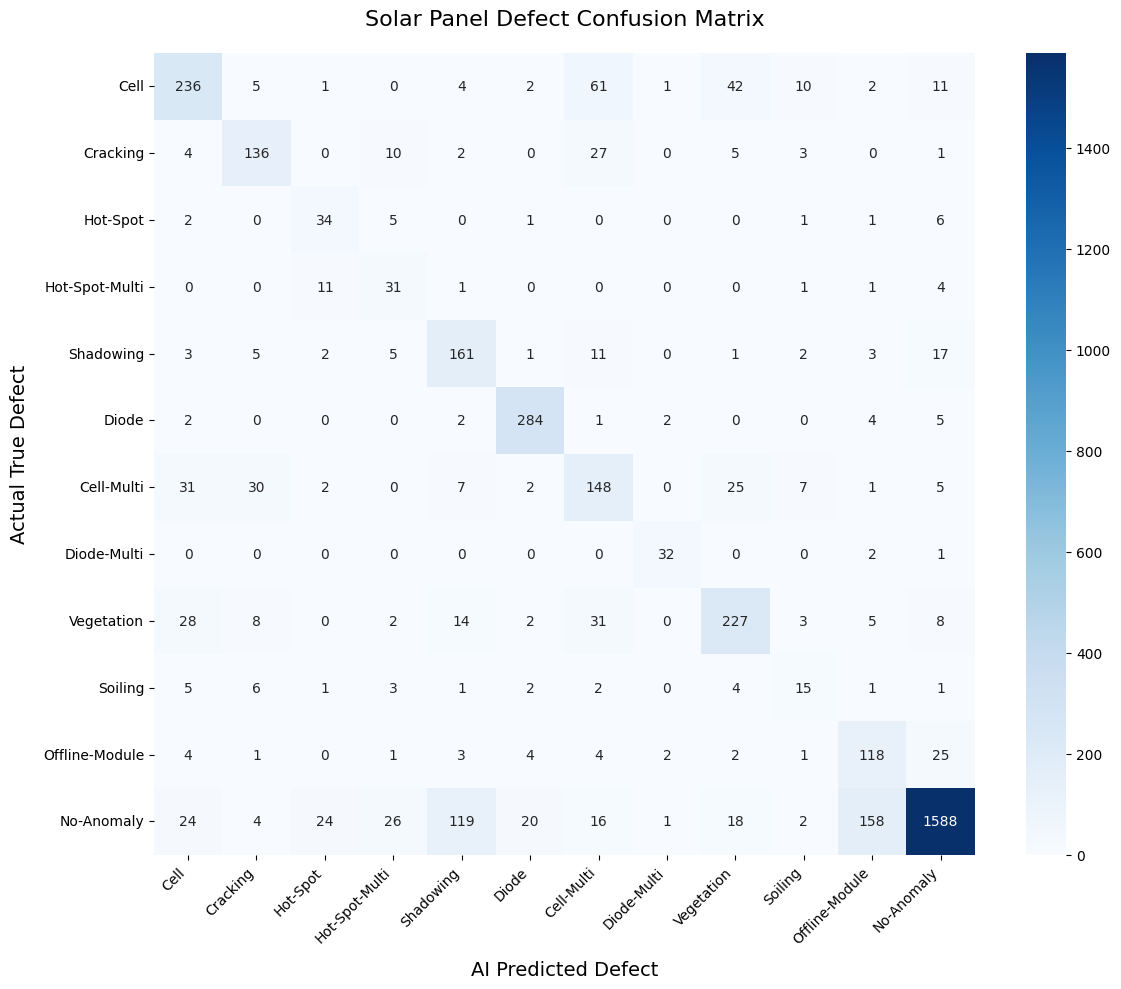

In [13]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("Running final evaluation on the Test Set...")
model.eval()

all_preds = []
all_labels = []
class_names = [
    "Cell", "Cracking", "Hot-Spot", "Hot-Spot-Multi",
    "Shadowing", "Diode", "Cell-Multi", "Diode-Multi",
    "Vegetation", "Soiling", "Offline-Module", "No-Anomaly"
]

with torch.no_grad():
    for images, labels in test_loaded: 
        images = images.to(device)
        labels = labels.to(device)
        class_preds, _ = model(images)
        _, predicted = torch.max(class_preds, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n CLASSIFICATION REPORT (Precision & Recall)")

report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print(report)

print("\n Confusion Matrix...")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Solar Panel Defect Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('AI Predicted Defect', fontsize=14, labelpad=10)
plt.ylabel('Actual True Defect', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()